# Using co-occurrences to find describing adjectives near Character Names

In [2]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
from tqdm.notebook import tqdm_notebook
from IPython.display import Markdown, display

tqdm_notebook.pandas()

In [3]:
BATCH_SIZE = 64
N_PROCESS = 4

#### Import gender, speakers and scripts

In [4]:
# load data
gender_df = pd.read_csv("../data/gender/gender.csv", encoding="utf-8")
print("loaded genders of", len(gender_df), "speakers")
scriptdata = pd.read_csv("../combine/combine.csv", encoding="utf-8")
print("loaded", len(scriptdata), "script lines")
speakers = pd.read_csv("../data/rolle.tsv", encoding="utf-8", delimiter="\t")
print("loaded", len(speakers), "speakers")
additional_speakers = pd.read_csv("../data/additional_roles.csv", encoding="utf-8")
print("loaded", len(additional_speakers), "additional_speakers")

loaded genders of 1680 speakers
loaded 145236 script lines
loaded 2485 speakers
loaded 989 additional_speakers


In [5]:
speakers = pd.concat(
    [speakers, additional_speakers], ignore_index=True
).drop_duplicates(subset=["name"], keep="first")
speakers

,rolleID,name
0,1,"Hitchcock, Erzähler"
1,2,"Justus Jonas, Erster Detektiv"
2,3,"Peter Shaw, Zweiter Detektiv"
3,4,"Bob Andrews, Recherchen und Archiv"
4,5,"Mr. Fentriss, Schriftsteller"
...,...,...
3469,-1,Jacob King
3470,-1,Soldat.
3471,1727,Tobin Miller
3472,-1,Leighs Mutter


#### Filter empty text lines and REGIE

In [6]:
scriptdata = scriptdata[~scriptdata["Text"].isna()]
scriptdata = scriptdata[scriptdata["speaker_id"] != 0]
#scriptdata = scriptdata.sample(n=3000, random_state=1)
scriptdata

,Speaker,Text,Page,speaker_id,Episode
1,Justus,"Hey, Peter, jemand ruft um Hilfe.",1,2,1
2,Peter,Ich hab's gehört. (zögert) War das nun ein Man...,1,3,1
3,Justus,"überlegt Hm, vielleicht keins von beiden. K...",1,2,1
4,Peter,verwundert Oder ob es Mr. Malcolm Fentriss w...,1,3,1
5,Justus,"Ich weiß nicht. Oh Mensch, Just, wir zieh'n lo...",1,2,1
...,...,...,...,...,...
145229,Peter,"Oh, nein...",80,3,225
145230,Bob,"Was denn, Squaredance? Och...das ist nicht eue...",80,4,225
145231,Justus,"Ich befürchte, doch...",80,2,225
145233,Peter,"Na, komm her, Justus, los. *lacht*",81,3,225


#### Split texts into sentences

In [7]:
nlp = spacy.load("de_core_news_lg")
nlp.add_pipe("sentencizer")

texts = scriptdata["Text"].tolist()
sentences = []

for doc in tqdm_notebook(
    nlp.pipe(texts, batch_size=BATCH_SIZE, n_process=N_PROCESS), total=len(texts)
):
    sentences.append([sent.text.strip() for sent in doc.sents])

scriptdata["sentences"] = sentences
scriptdata = scriptdata.explode("sentences")
scriptdata = scriptdata[~scriptdata["sentences"].isna()]
scriptdata = scriptdata.drop(columns=["Text"])
scriptdata

  0%|          | 0/130144 [00:00<?, ?it/s]

,Speaker,Page,speaker_id,Episode,sentences
1,Justus,1,2,1,"Hey, Peter, jemand ruft um Hilfe."
2,Peter,1,3,1,Ich hab's gehört.
2,Peter,1,3,1,(zögert)
2,Peter,1,3,1,War das nun ein Mann oder eine Frau?
3,Justus,1,2,1,"überlegt Hm, vielleicht keins von beiden."
...,...,...,...,...,...
145233,Peter,81,3,225,"Na, komm her, Justus, los."
145233,Peter,81,3,225,*lacht*
145234,Justus,81,2,225,"Ach, hey!"
145234,Justus,81,2,225,Schubs mich doch nicht!


#### Build stopword set
- manually inserted for adjective search
- adjectives usually don't need stopword deletion
- we manually insert the ones we find in our analysis and want to exclude

In [66]:
stopwords = set([
    'erster',
    'erstes',
    'zweiter'
    'nächster',
    'nächsten',
    'nächstes',
    'nächste',
    '1.',
])

#### Create a name to gender lookup

In [130]:
# join speaker and gender dataframes
# inner join makes sure we only keep speakers with a known gender
speakers_with_gender = speakers.merge(gender_df, on="rolleID", how="inner")
#speakers_with_gender.loc[-1] = [13, "Tante", "f"]  # adding a row
#speakers_with_gender.index = speakers_with_gender.index + 1  # shifting index
#speakers_with_gender = speakers_with_gender.sort_index()  # sorting by index

m_pronouns = ["er", "ihn", "ihm", "seiner", "sein", "seine", "seinen", "seinem", "seiner", "seines"]
m_relationship_words = ["Vater", "Sohn", "Bruder", "Opa", "Onkel", "Großvater", "Stiefvater", "Schwiegervater", "Schwager", "Neffe", "Enkel", "Männlicher Partner", "Ehemann", "Gatte", "Lebensgefährte", "Vetter", "Cousin"]
f_pronouns = ["sie", "ihr", "ihrer", "ihre", "ihren", "ihrem", "ihrer", "ihren", "ihres"]
f_relationship_words = ["Mutter", "Tochter", "Schwester", "Oma", "Tante", "Großmutter", "Stiefmutter", "Schwiegermutter", "Schwägerin", "Nichte", "Enkelin", "Ehefrau", "Gattin", "Lebensgefährtin", "Cousine"]

additional = pd.DataFrame({
   "rolleID": [-1]*(len(m_pronouns)+len(m_relationship_words)+len(f_pronouns)+len(f_relationship_words)),
    "name": m_pronouns + m_relationship_words + f_pronouns + f_relationship_words,
    "gender": ['m']*(len(m_pronouns)+len(m_relationship_words))+['f']*(len(f_pronouns)+len(f_relationship_words)),
})
speakers_with_gender = pd.concat([speakers_with_gender, additional], ignore_index=True)

# create a speaker name to gender lookup
name_to_gender = dict(
    zip(
        speakers_with_gender["name"].str.lower().str.strip(),
        speakers_with_gender["gender"],
    )
)

# create character name set
character_name_set = set(name_to_gender.keys())
print(f"Lookup Set contains {len(character_name_set)} characters")

Lookup Set contains 1919 characters


#### filter out sentences that do NOT contain character names

In [110]:
# create regex pattern to find character names (case insensitive)
name_pattern = re.compile(
    "|".join(r"\b" + re.escape(name) + r"\b" for name in character_name_set),
    re.IGNORECASE
)

# copy/filter sentences that contain character names
character_rows = scriptdata[
    scriptdata["sentences"].notna()
    & scriptdata["sentences"].str.contains(name_pattern, regex=True)
].copy()

print(
    f"found {len(character_rows)} lines containing character names out of {len(scriptdata)} total"
)

found 72394 lines containing character names out of 257244 total


#### Find character name - adjective pairs

In [111]:
reverse_lemma_lookup = defaultdict(set)

def get_gender_adj_pairs(doc):

    m_found = False
    f_found = False
    adjectives = []

    tokens = [
        token
        for token in list(doc)
        if (
            not token.is_punct
            and not token.is_digit
            and not token.is_space
            and not token.lower_ in stopwords
            and not token.lemma_.lower() in stopwords
        )
    ]
    # print(tokens)

    for i, tok in enumerate(tokens):
        gender = name_to_gender.get(tok.lower_)
        if gender is not None and gender == 'f':
            f_found = True
        elif gender is not None and gender == 'm':
            m_found = True
            # print(f'Found character {tok.lower_} in tokens {tokens}')
        elif tok.pos_ == "ADJ":
            # save adjectives lemma
            adjectives.append((tok.lemma_.lower()))
            # append to reverse lookup, we can use this later to find the original form of the lemmatised token
            reverse_lemma_lookup[tok.lemma_.lower()].add(tok.text)
            # print(f'Found adj {tok.lemma_.lower()} in tokens {tokens}')

    pairs = []
    for adj in adjectives:
        if m_found:
            pairs.append(('m', adj))
        if f_found:
            pairs.append(('f', adj))
        # TODO for future work: use np.abs(name_idx-adj_idx) to add information about the adj-name distance
    return pairs

In [112]:
nlp = spacy.load("de_core_news_lg")
gender_adj_pairs = []

sentences = character_rows["sentences"].tolist()
for doc in tqdm_notebook(
    nlp.pipe(sentences, batch_size=BATCH_SIZE, n_process=N_PROCESS),
    total=len(sentences),
):
    gender_adj_pairs.extend(get_gender_adj_pairs(doc))

print(gender_adj_pairs[:10])
print(f"{len(gender_adj_pairs)} (gender, adj) pairs found")
print(f"filled reverse lemma lookup with {len(reverse_lemma_lookup)} entries")

  0%|          | 0/72394 [00:00<?, ?it/s]

[('m', 'verschwunden'), ('m', 'kompliziert'), ('m', 'berühmt'), ('f', 'gefiedert'), ('m', 'zweiter'), ('m', 'dritt'), ('f', 'eigen'), ('f', 'verschwunden'), ('m', 'einsam'), ('m', 'aussehend')]
16051 (gender, adj) pairs found
filled reverse lemma lookup with 2917 entries


#### Example for reverse lemma lookup

In [113]:
print(
    f"Example for reverse lemma lookup: lemmas for adjective {gender_adj_pairs[0][1]}: {reverse_lemma_lookup[gender_adj_pairs[0][1]]}"
)

Example for reverse lemma lookup: lemmas for adjective verschwunden: {'verschwundene', 'verschwundenen', 'verschwundener'}


#### Create dataframe for statistical tests
- count gender-adj combination
- create df
- sort by frequency
- filter: only keep those who occure in both settings (female and male)

In [114]:
# Create DataFrame
gender_adj_df = pd.DataFrame(gender_adj_pairs, columns=["gender", "adjective"])

# Count occurrences of each (adjective, gender) pair
gender_adj_df = gender_adj_df.groupby(["adjective", "gender"]).size().unstack(fill_value=0)

# Rename columns and reset index
gender_adj_df.columns = ["f_count", "m_count"]
gender_adj_df = gender_adj_df.reset_index()

gender_adj_df = gender_adj_df.sort_values(['f_count', "m_count"], ascending=False)
gender_adj_df = gender_adj_df[(gender_adj_df['f_count']>=1) & (gender_adj_df['m_count'] >= 1)]

gender_adj_df

,adjective,f_count,m_count
97,alt,270,317
115,anderer,216,261
1428,klein,212,271
1179,groß,205,284
904,ganz,191,275
...,...,...,...
2807,zusammengewürfelt,1,1
2809,zustimmender,1,1
2814,zweifelhaft,1,1
2825,zäh,1,1


#### Calculate the totals for the Contingency Table 
for each adjective X we create a Contingency Table that looks like this

|                  | Male*                   | Female*                 | Total             |
| -------------    | -------------           | -------------           | -------------     |
| ADJ (e.g. 'alt') | df['m_count']           | df['f_count']           | df['total_count'] |
| Other Adjectives | m_total − df['m_count'] | f_total − df['f_count'] | f_m_total -  df['total_count']         |
| Total            | m_total                 | f_total                 | f_m_total         |

#### Lets calculate the adjective-independent cells of the contingency table

In [115]:
m_total = gender_adj_df["m_count"].sum()
f_total = gender_adj_df["f_count"].sum()
f_m_total = m_total + f_total

print(
    f"there are {m_total} occurrences of adjectives in sentences that contained a male character"
)
print(
    f"there are {f_total} occurrences of adjectives in sentences that contained a female character"
)
print(
    f"there are {f_m_total} occurrences of adjectives in sentences that contained a female or male character"
)

there are 7985 occurrences of adjectives in sentences that contained a male character
there are 5882 occurrences of adjectives in sentences that contained a female character
there are 13867 occurrences of adjectives in sentences that contained a female or male character


#### Lets calculate the adjective dependent cells

In [116]:
gender_adj_df["total_count"] = gender_adj_df["f_count"] + gender_adj_df["m_count"]
gender_adj_df['other_m_count'] = m_total - gender_adj_df["m_count"]
gender_adj_df['other_f_count'] = f_total - gender_adj_df["f_count"]
gender_adj_df['other_total_count'] = f_m_total - gender_adj_df["total_count"]
gender_adj_df

,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count
97,alt,270,317,587,7668,5612,13280
115,anderer,216,261,477,7724,5666,13390
1428,klein,212,271,483,7714,5670,13384
1179,groß,205,284,489,7701,5677,13378
904,ganz,191,275,466,7710,5691,13401
...,...,...,...,...,...,...,...
2807,zusammengewürfelt,1,1,2,7984,5881,13865
2809,zustimmender,1,1,2,7984,5881,13865
2814,zweifelhaft,1,1,2,7984,5881,13865
2825,zäh,1,1,2,7984,5881,13865


#### Lets calculate the expected values for LL

In [117]:
gender_adj_df["E_m"] = m_total * gender_adj_df["total_count"] / f_m_total
gender_adj_df["E_f"] = f_total * gender_adj_df["total_count"] / f_m_total

#gender_adj_df["E_m_other"] = (gender_adj_df["other_total_count"] * m_total) / f_m_total
#gender_adj_df["E_f_other"] = (gender_adj_df["other_total_count"] * f_total) / f_m_total

gender_adj_df.head(5)

,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f
97,alt,270,317,587,7668,5612,13280,338.010745,248.989255
115,anderer,216,261,477,7724,5666,13390,274.669719,202.330281
1428,klein,212,271,483,7714,5670,13384,278.124685,204.875315
1179,groß,205,284,489,7701,5677,13378,281.579650,207.420350
904,ganz,191,275,466,7710,5691,13401,268.335617,197.664383


#### Lets calculate Log Likelihood
- O: observed
- E: expected
- $LL=2\sum_i O_i*ln(\frac{O_i}{E_i})$
- i is the cell


|                  | Male*                   | Female*                 |
| -------------    | -------------           | -------------          |
| ADJ (e.g. 'alt') | O: m_count<br>E: E_m       | O: f_count<br>E: E_f        |
| Other Adjectives | O: other_m_count<br>E: E_m_other | O: other_f_count<br>E: E_f_other |

In [118]:
def safe_ll(observed, expected):
    return np.where(
        (observed > 0) & (expected > 0), observed * np.log(observed / expected), 0.0
    )


gender_adj_df["LL"] = (
    2
    * (
        safe_ll(gender_adj_df["m_count"], gender_adj_df["E_m"])
        + safe_ll(gender_adj_df["f_count"], gender_adj_df["E_f"])
        #+ safe_ll(gender_adj_df["other_m_count"], gender_adj_df["E_m_other"])
        #+ safe_ll(gender_adj_df["other_f_count"], gender_adj_df["E_f_other"])
    )
).round(3)
gender_adj_df = gender_adj_df.sort_values("LL", ascending=False).reset_index()
gender_adj_df.head(20)

,index,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f,LL
0,2820,zweiter,70,278,348,7707,5812,13519,200.387971,147.612029,77.562
1,1395,jung,53,141,194,7844,5829,13673,111.710536,82.289464,19.029
2,2058,schwarz,55,139,194,7846,5827,13673,111.710536,82.289464,16.440
3,2473,verdammt,21,6,27,7979,5861,13840,15.547343,11.452657,14.039
4,2079,schön,42,23,65,7962,5840,13802,37.428788,27.571212,12.956
5,2037,schmutzig,1,10,11,7975,5881,13856,6.334103,4.665897,6.052
6,1543,leis,1,10,11,7975,5881,13856,6.334103,4.665897,6.052
7,2480,verehrt,6,1,7,7984,5876,13860,4.030793,2.969207,5.654
8,669,enorm,6,1,7,7984,5876,13860,4.030793,2.969207,5.654
9,1544,leise,3,15,18,7970,5879,13849,10.364895,7.635105,5.484


#### Use survival function of Chi-Squared Distribution to get p-values

In [119]:
# calculate p-value using Chi-Squared (https://en.wikipedia.org/wiki/Chi-squared_test)
gender_adj_df["p_value"] = chi2.sf(gender_adj_df["LL"], df=1)
gender_adj_df

,index,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f,LL,p_value
0,2820,zweiter,70,278,348,7707,5812,13519,200.387971,147.612029,77.562,1.286210e-18
1,1395,jung,53,141,194,7844,5829,13673,111.710536,82.289464,19.029,1.287468e-05
2,2058,schwarz,55,139,194,7846,5827,13673,111.710536,82.289464,16.440,5.021437e-05
3,2473,verdammt,21,6,27,7979,5861,13840,15.547343,11.452657,14.039,1.790581e-04
4,2079,schön,42,23,65,7962,5840,13802,37.428788,27.571212,12.956,3.188978e-04
...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1276,herzlich,3,4,7,7981,5879,13860,4.030793,2.969207,0.001,9.747729e-01
1096,369,bestimmt,22,30,52,7955,5860,13815,29.943030,22.056970,0.000,1.000000e+00
1097,1633,merkwürdig,22,30,52,7955,5860,13815,29.943030,22.056970,0.000,1.000000e+00
1098,2262,toll,11,15,26,7970,5871,13841,14.971515,11.028485,0.000,1.000000e+00


#### Calculate log odds and log odds ratio to get interpretable magnitude

In [120]:
gender_adj_df["log_odds"] = np.log(
    (gender_adj_df["f_count"] / f_total) /
    (gender_adj_df["m_count"] / m_total)
)
gender_adj_df["odds_ratio"] = np.exp(gender_adj_df["log_odds"])
gender_adj_df["direction"] = np.where(
    gender_adj_df["log_odds"] > 0, "female", "male"
)
gender_adj_df

,index,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f,LL,p_value,log_odds,odds_ratio,direction
0,2820,zweiter,70,278,348,7707,5812,13519,200.387971,147.612029,77.562,1.286210e-18,-1.073458,0.341824,male
1,1395,jung,53,141,194,7844,5829,13673,111.710536,82.289464,19.029,1.287468e-05,-0.672800,0.510278,male
2,2058,schwarz,55,139,194,7846,5827,13673,111.710536,82.289464,16.440,5.021437e-05,-0.621473,0.537153,male
3,2473,verdammt,21,6,27,7979,5861,13840,15.547343,11.452657,14.039,1.790581e-04,1.558431,4.751360,female
4,2079,schön,42,23,65,7962,5840,13802,37.428788,27.571212,12.956,3.188978e-04,0.907843,2.478970,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1276,herzlich,3,4,7,7981,5879,13860,4.030793,2.969207,0.001,9.747729e-01,0.017986,1.018149,female
1096,369,bestimmt,22,30,52,7955,5860,13815,29.943030,22.056970,0.000,1.000000e+00,-0.004487,0.995523,male
1097,1633,merkwürdig,22,30,52,7955,5860,13815,29.943030,22.056970,0.000,1.000000e+00,-0.004487,0.995523,male
1098,2262,toll,11,15,26,7970,5871,13841,14.971515,11.028485,0.000,1.000000e+00,-0.004487,0.995523,male


#### Adjust for multiple testing error using false discovery rate (fdr) with Benjamini/Hochberg (non-negative)

In [121]:
# correct p value using benjamini-hochberg fdr-correction with default alpha of 0.05
reject, p_adjusted, _, _ = multipletests(gender_adj_df["p_value"], method="fdr_bh", alpha=0.1)
gender_adj_df["p_adjusted"] = p_adjusted
gender_adj_df["significant"] = reject

gender_adj_df.head(10)

,index,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f,LL,p_value,log_odds,odds_ratio,direction,p_adjusted,significant
0,2820,zweiter,70,278,348,7707,5812,13519,200.387971,147.612029,77.562,1.286210e-18,-1.073458,0.341824,male,1.414831e-15,True
1,1395,jung,53,141,194,7844,5829,13673,111.710536,82.289464,19.029,1.287468e-05,-0.672800,0.510278,male,7.081076e-03,True
2,2058,schwarz,55,139,194,7846,5827,13673,111.710536,82.289464,16.440,5.021437e-05,-0.621473,0.537153,male,1.841193e-02,True
3,2473,verdammt,21,6,27,7979,5861,13840,15.547343,11.452657,14.039,1.790581e-04,1.558431,4.751360,female,4.924099e-02,True
4,2079,schön,42,23,65,7962,5840,13802,37.428788,27.571212,12.956,3.188978e-04,0.907843,2.478970,female,7.015752e-02,True
5,2037,schmutzig,1,10,11,7975,5881,13856,6.334103,4.665897,6.052,1.389055e-02,-1.996917,0.135753,male,9.102948e-01,False
6,1543,leis,1,10,11,7975,5881,13856,6.334103,4.665897,6.052,1.389055e-02,-1.996917,0.135753,male,9.102948e-01,False
7,2480,verehrt,6,1,7,7984,5876,13860,4.030793,2.969207,5.654,1.741560e-02,2.097427,8.145189,female,9.102948e-01,False
8,669,enorm,6,1,7,7984,5876,13860,4.030793,2.969207,5.654,1.741560e-02,2.097427,8.145189,female,9.102948e-01,False
9,1544,leise,3,15,18,7970,5879,13849,10.364895,7.635105,5.484,1.919129e-02,-1.303770,0.271506,male,9.102948e-01,False


In [122]:
# remove un-significant adjectives
significant = gender_adj_df[gender_adj_df['significant']]
print(
    "Top male-biased: "
    + ", ".join(significant[significant["direction"] == "male"].head(10)["adjective"])
)
print(
    "Top female-biased: "
    + ", ".join(significant[significant["direction"] == "female"].head(10)["adjective"])
)
significant

Top male-biased: zweiter, jung, schwarz
Top female-biased: verdammt, schön


,index,adjective,f_count,m_count,total_count,other_m_count,other_f_count,other_total_count,E_m,E_f,LL,p_value,log_odds,odds_ratio,direction,p_adjusted,significant
0,2820,zweiter,70,278,348,7707,5812,13519,200.387971,147.612029,77.562,1.286210e-18,-1.073458,0.341824,male,1.414831e-15,True
1,1395,jung,53,141,194,7844,5829,13673,111.710536,82.289464,19.029,1.287468e-05,-0.672800,0.510278,male,7.081076e-03,True
2,2058,schwarz,55,139,194,7846,5827,13673,111.710536,82.289464,16.440,5.021437e-05,-0.621473,0.537153,male,1.841193e-02,True
3,2473,verdammt,21,6,27,7979,5861,13840,15.547343,11.452657,14.039,1.790581e-04,1.558431,4.751360,female,4.924099e-02,True
4,2079,schön,42,23,65,7962,5840,13802,37.428788,27.571212,12.956,3.188978e-04,0.907843,2.478970,female,7.015752e-02,True


#### Sort by odds ratio (magnitude)

In [123]:
# drop helper columns and sort
gender_adj_df = (
    gender_adj_df
    .drop(columns=["other_m_count", "other_f_count", "other_total_count", "E_m", "E_f", "E_m_other", "E_f_other"], errors='ignore')
    .sort_values("odds_ratio", ascending=False).reset_index()
)
gender_adj_df.head(20)

,level_0,index,adjective,f_count,m_count,total_count,LL,p_value,log_odds,odds_ratio,direction,p_adjusted,significant
0,7,2480,verehrt,6,1,7,5.654,0.017416,2.097427,8.145189,female,0.910295,False
1,8,669,enorm,6,1,7,5.654,0.017416,2.097427,8.145189,female,0.910295,False
2,16,1236,heimlich,5,1,6,4.273,0.038723,1.915106,6.787657,female,0.910295,False
3,35,619,eingerichtet,4,1,5,2.961,0.085295,1.691962,5.430126,female,0.910295,False
4,34,335,bemalt,4,1,5,2.961,0.085295,1.691962,5.430126,female,0.910295,False
5,32,989,geldgierig,4,1,5,2.961,0.085295,1.691962,5.430126,female,0.910295,False
6,36,2870,übernatürlich,4,1,5,2.961,0.085295,1.691962,5.430126,female,0.910295,False
7,33,2001,scheußlich,4,1,5,2.961,0.085295,1.691962,5.430126,female,0.910295,False
8,14,1637,mexikanisch,7,2,9,4.680,0.030516,1.558431,4.751360,female,0.910295,False
9,13,2293,tödlich,7,2,9,4.680,0.030516,1.558431,4.751360,female,0.910295,False


In [124]:
gender_adj_df.tail(20)

,level_0,index,adjective,f_count,m_count,total_count,LL,p_value,log_odds,odds_ratio,direction,p_adjusted,significant
1080,75,760,erwähnt,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1081,74,1959,rund,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1082,73,559,dunkelhaarig,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1083,77,1143,glänzend,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1084,9,1544,leise,3,15,18,5.484,0.019191,-1.303770,0.271506,male,0.910295,False
1085,81,2005,schief,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1086,80,2842,äußerer,1,5,6,1.828,0.176364,-1.303770,0.271506,male,0.910295,False
1087,45,2567,verstellt,1,6,7,2.597,0.107066,-1.486092,0.226255,male,0.910295,False
1088,44,2808,zustimmend,1,6,7,2.597,0.107066,-1.486092,0.226255,male,0.910295,False
1089,28,1672,modern,1,7,8,3.414,0.064646,-1.640242,0.193933,male,0.910295,False


---

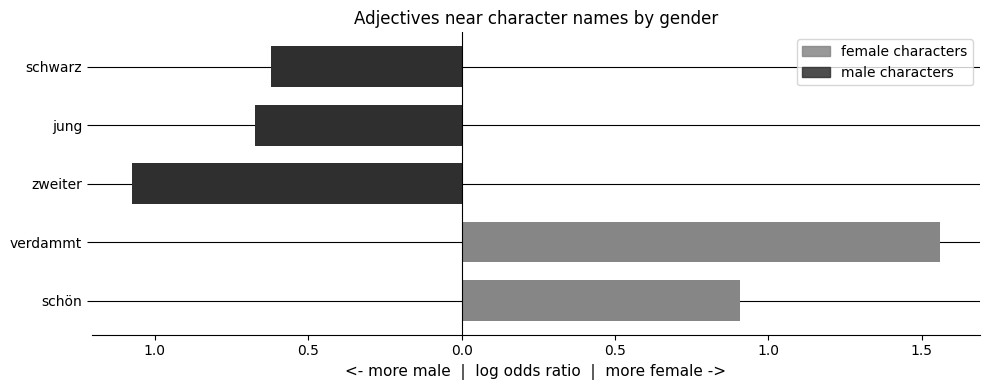

Saved adj_gender_window.png


<Figure size 640x480 with 0 Axes>

In [125]:
F_COLOR = "#868686"
M_COLOR = "#2f2f2f"

def plot_diverging(df, title, filename, top_n=20):
    male_top = df[df["direction"] == "male"].head(top_n).copy()
    female_top = df[df["direction"] == "female"].head(top_n).copy()

    # log_odds is already signed -> positive = female, negative = male
    # flip male to negative for the diverging axis
    male_top["log_odds_signed"] = -male_top["log_odds"].abs()
    female_top["log_odds_signed"] = female_top["log_odds"].abs()

    # sort values for top most values for each gender
    plot_df = pd.concat([
        female_top.sort_values("log_odds_signed"),
        male_top.sort_values("log_odds_signed"),
    ])

    colors = [F_COLOR if v > 0 else M_COLOR for v in plot_df["log_odds_signed"]]

    # variable size depending on how many words we display
    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_df) * 0.35)))
    ax.barh(
        plot_df["adjective"],
        plot_df["log_odds_signed"],
        color=colors,
        edgecolor="none",
        #alpha=0.85,  # opacity
        height=0.7
    )

    ax.yaxis.grid(True, linestyle="-", linewidth=0.8, color="black")#, alpha=0.5)
    ax.set_axisbelow(True)  # keeps grid lines behind the bars

    # insert vertical line at 0 (diverging axis)
    ax.axvline(0, color="black", linewidth=0.8)

    # label and title
    ax.set_xlabel("<- more male  |  log odds ratio  |  more female ->", fontsize=11)
    ax.set_title(title, fontsize=12)

    # Show absolute log odds on the axis ticks
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{abs(x):.1f}"))

    male_patch = mpatches.Patch(color=M_COLOR, alpha=0.85, label="male characters")
    female_patch = mpatches.Patch(color=F_COLOR, alpha=0.85, label="female characters")
    ax.legend(handles=[female_patch, male_patch])
    ax.spines[["top", "right", "left"]].set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"./{filename}", dpi=150)
    print(f"Saved {filename}")

plot_diverging(
    significant, "Adjectives near character names by gender", "adj_gender_window.png"
)

---

#### In this part we demonstrate how to view a specific keyword (adj) in its context

In [88]:
base_forms = sorted(list(reverse_lemma_lookup['verdammt']), key=len, reverse=True)
base_forms

['verdammter', 'verdammtes', 'verdammten', 'verdammte']

In [89]:
pattern = "|".join(base_forms)
matching_sentences = list(character_rows[character_rows["sentences"].str.contains(pattern, na=False)]['sentences'])
for idx, sentence in enumerate(matching_sentences):
    for bf in base_forms:
        if bf in sentence:
            matching_sentences[idx] = sentence.replace(bf, f'**{bf}**')
            break
for sentence in matching_sentences:
    display(Markdown(sentence))

Ach, ihr **verdammten** Bengel!

Das **verdammte** Tal mit seinem Geheul!

Und wenn King doch mit diesem **verdammten** Speed zu tun hat?

Und nun ist uns tatsächlich jemand auf die Spur gekommen, aber nicht der **verdammte** Zoll oder die Polizei sondern ein Junge, der glaubt, wir seien seine Eltern.

Nachdem du uns vorhin so plötzlich vor die Tür gesetzt hattest, wurde ich das **verdammte** Gefühl nicht los, dass ich diesem Frank vorher schonmal irgendwo begegnet bin.

...

Außerdem trägt er sein **verdammtes** Schachbrett ständig mit sich herum.

Ihr **verdammten** kleinen...

Ihr **verdammten** Schnüffler!

Stehen bleiben, ihr **verdammten** Strauchdiebe!

Nimm mir diese **verdammten** Handschellen ab, Katee!